# Step 1: Import Required Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset

In [20]:
df = pd.read_csv("../data/raw/Chronic_Kidney_Disease_200K_40Columns.csv")

In [21]:
df.shape
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   patient_id                 200000 non-null  int64  
 1   age                        200000 non-null  int64  
 2   gender                     200000 non-null  object 
 3   bmi                        200000 non-null  float64
 4   blood_pressure_systolic    200000 non-null  int64  
 5   blood_pressure_diastolic   200000 non-null  int64  
 6   serum_creatinine           200000 non-null  float64
 7   blood_urea                 200000 non-null  float64
 8   egfr                       200000 non-null  float64
 9   albumin                    200000 non-null  int64  
 10  hemoglobin                 200000 non-null  float64
 11  red_blood_cells            200000 non-null  object 
 12  pus_cell                   200000 non-null  object 
 13  pus_cell_clumps            20

,patient_id,age,bmi,blood_pressure_systolic,blood_pressure_diastolic,serum_creatinine,blood_urea,egfr,albumin,hemoglobin,...,sodium,potassium,calcium,phosphorus,urine_protein,urine_specific_gravity,cholesterol,heart_rate,hospital_visits_last_year,medications_count
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,54.036520,27.003377,139.390985,89.502815,1.811234,45.216187,65.079513,2.501935,12.497775,...,138.004163,4.499513,9.201466,4.001383,2.504462,1.017510,209.411840,84.547860,6.988695,5.489885
std,57735.171256,21.063637,4.990390,28.866757,17.291897,0.778354,19.604012,24.657159,1.707624,2.001307,...,4.003123,0.800069,0.798921,0.997305,1.442590,0.007239,63.412057,20.188704,4.316085,3.454459
min,1.000000,18.000000,2.400000,90.000000,60.000000,0.300000,5.000000,5.000000,0.000000,5.000000,...,120.000000,2.000000,6.000000,1.000000,0.000000,1.005000,100.000000,50.000000,0.000000,0.000000
25%,50000.750000,36.000000,23.600000,114.000000,75.000000,1.270000,31.600000,48.200000,1.000000,11.100000,...,135.300000,4.000000,8.700000,3.300000,1.260000,1.011000,155.000000,67.000000,3.000000,2.000000
50%,100000.500000,54.000000,27.000000,139.000000,90.000000,1.800000,45.000000,65.000000,3.000000,12.500000,...,138.000000,4.500000,9.200000,4.000000,2.500000,1.018000,209.000000,85.000000,7.000000,5.000000
75%,150000.250000,72.000000,30.400000,164.000000,104.000000,2.340000,58.600000,81.900000,4.000000,13.900000,...,140.700000,5.000000,9.700000,4.700000,3.760000,1.024000,264.000000,102.000000,11.000000,8.000000
max,200000.000000,90.000000,50.400000,189.000000,119.000000,5.330000,131.300000,130.000000,5.000000,20.000000,...,155.000000,8.000000,12.000000,8.000000,5.000000,1.030000,319.000000,119.000000,14.000000,11.000000


# Step 3:Missing Values Analysis

In [22]:
df.isnull().sum()

patient_id                   0
age                          0
gender                       0
bmi                          0
blood_pressure_systolic      0
blood_pressure_diastolic     0
serum_creatinine             0
blood_urea                   0
egfr                         0
albumin                      0
hemoglobin                   0
red_blood_cells              0
pus_cell                     0
pus_cell_clumps              0
bacteria                     0
blood_glucose_random         0
sodium                       0
potassium                    0
calcium                      0
phosphorus                   0
diabetes_mellitus            0
hypertension                 0
coronary_artery_disease      0
appetite                     0
pedal_edema                  0
anemia                       0
smoking_status               0
alcohol_use                  0
physical_activity            0
family_history_ckd           0
urine_protein                0
urine_specific_gravity       0
choleste

<Axes: >

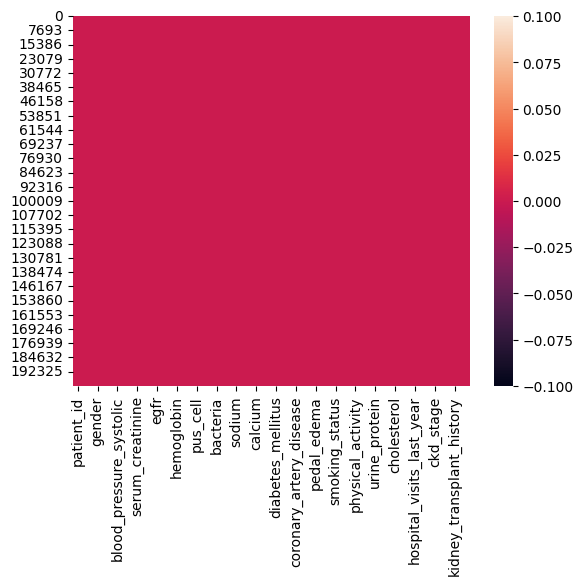

In [23]:
import seaborn as sns

sns.heatmap(df.isnull())

# Step 4:Data Cleaning

## Remove Duplicates

In [24]:
df.drop_duplicates(inplace=True)

## Handle Missing Values

In [25]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
median_values = df[num_cols].median()
df[num_cols] = df[num_cols].fillna(median_values)

In [26]:
cat_cols = df.select_dtypes(include='object').columns
mode_values = df[cat_cols].mode().iloc[0]  # Get first row of mode results
df[cat_cols] = df[cat_cols].fillna(mode_values)

# Step 5:Feature Engineering

## High Blood Pressure

In [27]:
df['high_bp']=(
    df['blood_pressure_systolic']>=140
).astype(int)

## Kidney Risk Score

In [28]:
df['kidney_risk_score']=(
    df['serum_creatinine']
    + df['blood_urea']
)

## Senior Citizen

In [29]:
df['senior_patient']=(
    df['age']>=60
).astype(int)

## Comorbidity Count

In [30]:
df['comorbidity_count']=(
    df['diabetes_mellitus'].map({'Yes':1,'No':0})
    +
    df['hypertension'].map({'Yes':1,'No':0})
)

# Step 6:Initial EDA

## CKD Distribution

<Axes: xlabel='ckd_diagnosis', ylabel='count'>

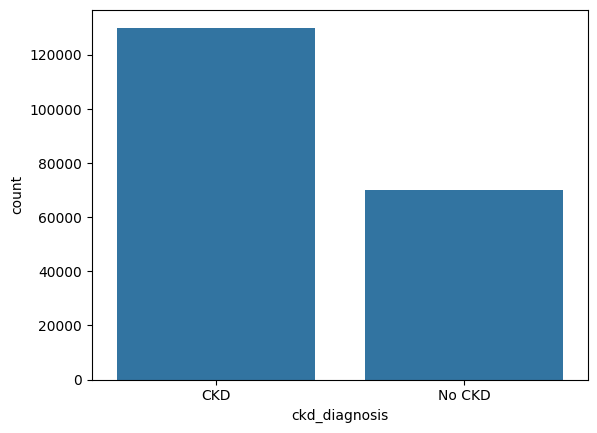

In [31]:
sns.countplot(
    x='ckd_diagnosis',
    data=df
)

## Gender Analysis

<Axes: xlabel='gender', ylabel='count'>

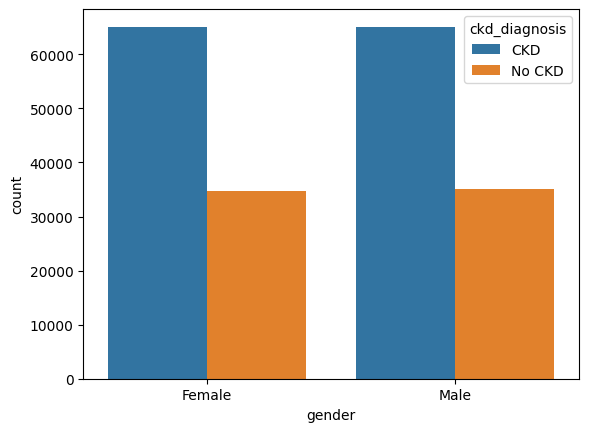

In [32]:
sns.countplot(
    x='gender',
    hue='ckd_diagnosis',
    data=df
)

## Age Analysis

<Axes: xlabel='ckd_diagnosis', ylabel='age'>

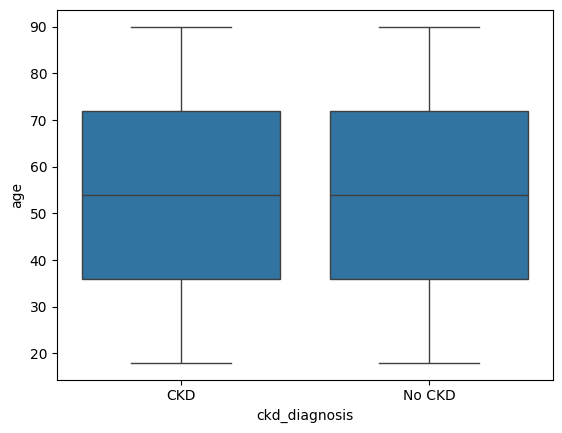

In [33]:
sns.boxplot(
    x='ckd_diagnosis',
    y='age',
    data=df
)

## Creatinine Analysis

<Axes: xlabel='ckd_diagnosis', ylabel='serum_creatinine'>

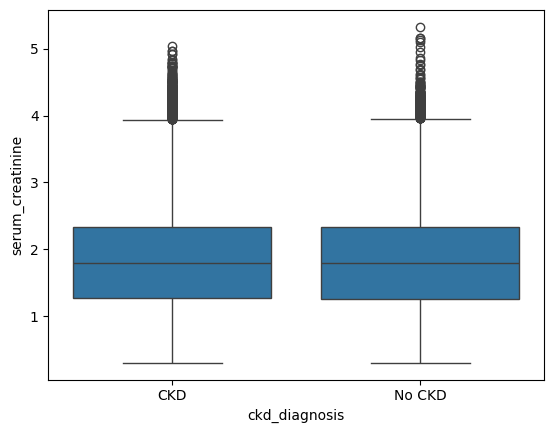

In [34]:
sns.boxplot(
    x='ckd_diagnosis',
    y='serum_creatinine',
    data=df
)

# Step 7:Correlation Analysis

<Axes: >

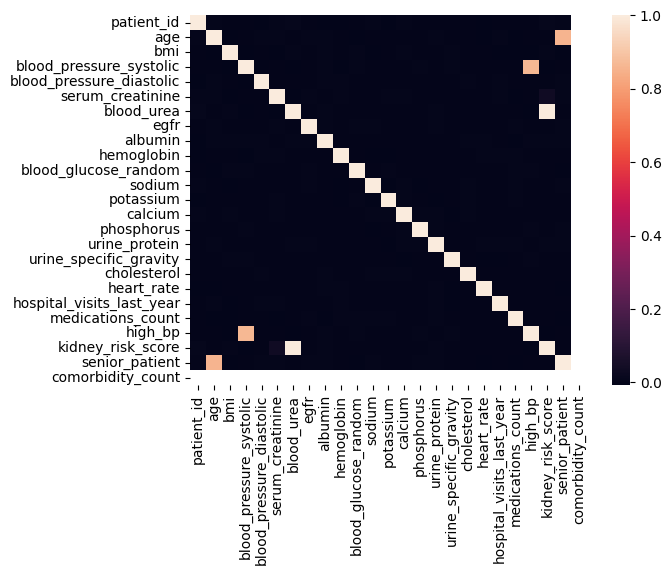

In [35]:
corr=df.corr(numeric_only=True)

sns.heatmap(corr)

# Step 8: Export Clean Dataset

In [36]:
df.to_csv(
    "../data/processed/cleaned_chronic_disease_analysis.csv",
    index=False
)